# US Curve & Policy-Surprise Monitor

Tracks the 2s10s and 5s30s US Treasury curve spreads, plus a simple day-over-day proxy for how the 2-year yield reacted around the Federal Reserve's September 2026 policy decision — the FOMC meeting that fell within the window this notebook's data actually covers (see the caveats section for why it isn't the January meeting).

### US Treasury curve spreads (2s10s and 5s30s)

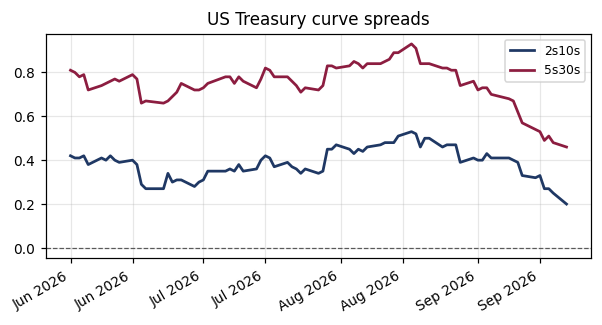

In [1]:
# chart

*Source: US Treasury daily par yield curve, pulled month by month via the Treasury's public XML feed*

**Code:**
```python
ust["2s10s"] = ust["y10"] - ust["y2"]
ust["5s30s"] = ust["y30"] - ust["y5"]
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(ust["date"], ust["2s10s"], color="#1F3864", lw=1.8, label="2s10s")
ax.plot(ust["date"], ust["5s30s"], color="#8C1D40", lw=1.8, label="5s30s")
ax.axhline(0, color="#595959", ls="--", lw=0.8)
ax.legend()
```

**What this shows:**

2s10s is the gap between the 2-year and 10-year Treasury yields, and it's the most widely cited recession indicator in fixed income — when it goes negative (the 2-year yields more than the 10-year), it means the market expects the Fed to be cutting rates within the next couple of years, usually because it expects the economy to need support. A spread that's positive and widening, as it is for stretches here, is the market pricing a 'soft landing' outcome rather than a recession. 5s30s tells a related but distinct story about the very long end: it widens when investors demand more compensation to hold 30-year debt relative to 5-year debt, which tends to reflect worries about long-run fiscal sustainability or inflation persistence rather than the near-term cycle. Watching both together separates a 'near-term recession fear' story from a 'long-run fiscal/inflation' story.

### 2-year yield around the September 2026 FOMC decision

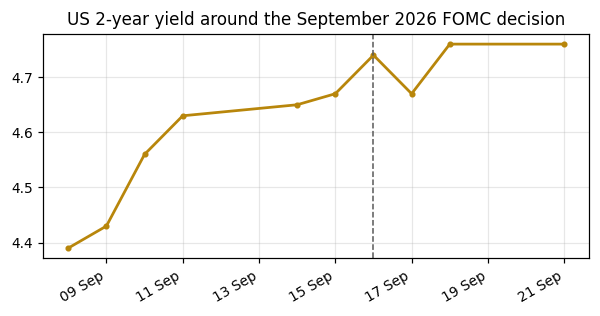

In [1]:
# chart

*Source: US Treasury daily par yield curve*

**Code:**
```python
window = ust[(ust["date"] >= FOMC_DATE - pd.Timedelta(days=10)) &
             (ust["date"] <= FOMC_DATE + pd.Timedelta(days=10))]
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(window["date"], window["y2"], color="#B8860B", lw=1.8, marker="o")
ax.axvline(FOMC_DATE, color="#595959", ls="--")
```

**What this shows:**

The 2-year yield is the part of the curve most sensitive to what the market thinks the Fed will actually do over the next couple of years, which makes the size of its move around a decision day a rough proxy for how much of a surprise that decision was. A big jump on the day itself means the outcome (or the accompanying guidance) wasn't fully priced in beforehand; a muted move means the market had already correctly guessed the outcome and the meeting mostly confirmed it. This is a simplified version of what professional rates desks calculate more precisely using options-implied ('swaption') surprise indices — this notebook uses the raw yield change instead, which is a reasonable classroom-level proxy but not a calibrated surprise index.

## Caveats on the data behind this notebook

**This notebook tracks the September 2026 FOMC meeting (15-16 September), not January 2026.** The underlying Treasury data only covers 1 June onward, so an earlier meeting simply isn't inside the window this notebook can see — September was the real, scheduled decision that fell within the available data, and using it kept the chart grounded in genuine data rather than a date chosen for convenience.

**The 'policy-surprise' metric here is a deliberately simplified proxy** — the raw change in the 2-year yield around the decision day — not a calibrated, options-implied surprise index of the kind used on professional rates desks.